In [1]:
import sys
import yaml

import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn import Identity, SELU
from torch.optim import Adam
import torchsde
from tqdm import tqdm
from matplotlib import rcParams
from scipy.special import softmax
import seaborn as sns
import pandas as pd

from collections.abc import Callable

import sc_exp_design 
from sc_exp_design.utils import sinusoidal_time_features
from sc_exp_design.utils import match_shapes
from sc_exp_design.data import DataManager, SequentialDataLoader
from sc_exp_design.flows import RectifiedFlow
from sc_exp_design.models import FlowMatching
from sc_exp_design.networks import MLPBlock

from guidance_scheduler import scaled_guidance_weight

# importing libraries
sys.path.insert(0, "../../../../")
from sweeps.dispatcher import fetch_adata

In [2]:
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE
# Set seaborn colorblind palette globally
sns.set_palette("colorblind")

## Host data

In [3]:
# defining path
# H5AD_DATA_PATH = "/lustre/groups/ml01/projects/inverse_perturbation_models/datasets/hein_et_al_cmv/cmv_infection.h5ad"
H5AD_DATA_PATH = "/nfs/homedirs/pala/sc_exp_design/scExpDesign-Reproducibility/project_folder/datasets/hein_et_al_cmv/cmv_infection.h5ad"

In [4]:
# leading adata
train_adata, _ = fetch_adata(
    "cmv_infection",
    H5AD_DATA_PATH,
    {
        "standardize_pcs": False
    }
)
train_adata

AnnData object with n_obs × n_vars = 12919 × 3482
    obs: 'index', 'cell_barcode', 'gem_group', 'UMI_count', 'guide_UMI_count', 'guide_read_count', 'guide_coverage', 'MOI', 'experimental_time', 'cell_cycle_phase', 'viral_load', 'interferon_score', 'cluster', 'UMAP_1', 'UMAP_2'
    var: 'ENSMBL', 'gene ID', 'mt', 'is_host', 'highly_variable'
    uns: 'cluster_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_counts_condition', 'X_pca', 'X_pca_condition', 'X_umap', 'X_umap_condition'
    varm: 'PCs'
    layers: 'X_counts'
    obsp: 'connectivities', 'distances'

Host UMAP

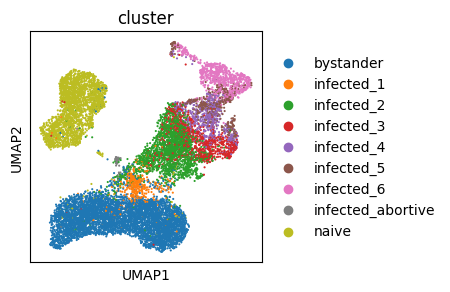

In [5]:
sc.pl.umap(train_adata, color="cluster")

Viral UMAP

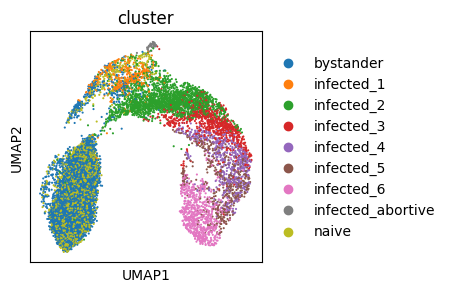

In [6]:
adata_viral = train_adata.copy()
sc.pp.neighbors(adata_viral, use_rep='X_pca_condition')
sc.tl.umap(adata_viral)
sc.pl.umap(adata_viral, color="cluster")

## Load target covariates

In [7]:
# reading data configuration
# DATA_CONFIG_PATH = "/home/icb/alessandro.palma/environment/scExpDesign-Reproducibility/bio_dataset_analysis/cmv_infection_dataset/config/data/default.yaml"
DATA_CONFIG_PATH = "/nfs/homedirs/pala/sc_exp_design/scExpDesign-Reproducibility/bio_dataset_analysis/cmv_infection_dataset/config/data/default.yaml"

with open(DATA_CONFIG_PATH, "r") as fp:
    data_config = yaml.safe_load(fp)
data_config

{'sample_rep': 'X_pca',
 'control_key': None,
 'perturbations': 'viral_genes',
 'perturbations_in_obsm': ['viral_genes'],
 'perturbation_covariates': None,
 'perturbation_reps': {'viral_genes': 'X_pca_condition'},
 'load_target_covariates': False,
 'target_covariates': None,
 'target_covariates_in_obsm': None,
 'target_covariates_kwargs': None}

In [8]:
# updating data configuration to also load target variable
data_config["load_target_covariates"] = True 
data_config["target_covariates"] = {
    "cluster": "label",
}
data_config

{'sample_rep': 'X_pca',
 'control_key': None,
 'perturbations': 'viral_genes',
 'perturbations_in_obsm': ['viral_genes'],
 'perturbation_covariates': None,
 'perturbation_reps': {'viral_genes': 'X_pca_condition'},
 'load_target_covariates': True,
 'target_covariates': {'cluster': 'label'},
 'target_covariates_in_obsm': None,
 'target_covariates_kwargs': None}

In [9]:
# initializing the data manager
datamanager = DataManager(
    train_adata,
    **data_config,
)

# retrieving train data
train_data = datamanager.get_data()

Check cluster 

In [10]:
print(train_data.target_data["cluster"])
print(train_data.target_data["cluster"].shape)

[0 6 0 ... 2 5 5]
(12919,)


In [11]:
np.unique(train_data.target_data["cluster"], return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 array([5446,  404, 2038,  804,  555,  509,  751,   39, 2373]))

## Load Forward Model

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

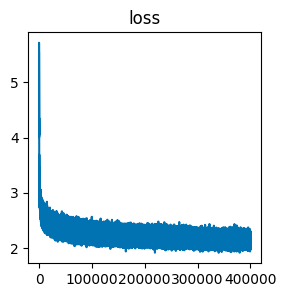

In [12]:
# define the model path
# MODEL_PATH = "/lustre/groups/ml01/projects/inverse_perturbation_models/dumps/cmv_infection/2025-06-19_19-33-51/eternal-forest-21_FlowMatching.pkl"
MODEL_PATH = "/nfs/homedirs/pala/sc_exp_design/scExpDesign-Reproducibility/project_folder/dumps/cmv_infection/oracle_ckpt/eternal-forest-21_FlowMatching.pkl"

# loading the model and plotting the training logs
flow_matching = FlowMatching.load(MODEL_PATH)
flow_matching.trainer.plot_training_logs()

## Target Prediction Model

Initialize the attribute predictive model

In [13]:
# defining device
device = torch.device("cuda")

# defining target dim
g_model_input_dim = train_data.state_data.shape[1]
g_model_output_dim = int(train_adata.obs[["cluster"]].nunique())

# initializing g model
g_model = MLPBlock(
    input_dim=g_model_input_dim,
    output_dim=g_model_output_dim,
    hidden_dims=(64,),
    use_batchnorm=False,
    use_dropout=False,
    dropout_rate=0.0,
    activation_class=SELU,
    final_activation_class=Identity,
)
g_model.to(device)

# defining optimizer
g_model_optimizer = Adam(g_model.parameters(), lr=1e-3)

/tmp/ipykernel_2635606/3898277513.py:6: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  g_model_output_dim = int(train_adata.obs[["cluster"]].nunique())


In [14]:
g_model

MLPBlock(
  (net): Sequential(
    (0): Sequential(
      (0): Linear(in_features=50, out_features=64, bias=True)
      (1): SELU()
    )
    (1): Sequential(
      (0): Linear(in_features=64, out_features=9, bias=True)
      (1): Identity()
    )
  )
)

Training setup for the attribute predictive model

In [15]:
# defining the batch size
batch_size = 256

# initializing data loader
train_dataloader = SequentialDataLoader(
    train_data,
    batch_size,
    state_transforms=None,
    device_id="cuda"
)

100%|██████████| 10000/10000 [00:18<00:00, 532.76it/s]


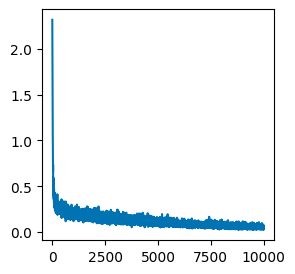

In [16]:
# defining number of grad steps and progess bar
num_grad_steps = 10_000
iterator = range(num_grad_steps)

# defining store for the loss
loss_history = torch.zeros((num_grad_steps))

# iterating over the number of gradient steps
for grad_step in tqdm(iterator):
    
    # sampling batch of data
    batch = train_dataloader.sample()

    # parsing batch dictionary
    states = batch["state_data"]
    cluster = batch["target_categories"]["cluster"]

    # forward pass on the model
    cluster_logits = g_model(states)

    # computing loss
    loss = torch.nn.functional.cross_entropy(cluster_logits, cluster.long())

    # backpropagation
    g_model_optimizer.zero_grad()
    loss.backward()
    g_model_optimizer.step()

    # storing the loss and updating the progress bar
    loss_history[grad_step] = loss.item()

# plotting loss history
plt.figure(figsize=(3, 3))
plt.plot(loss_history)

## Flow prior

Input perturbation data

In [17]:
perturbation_data = train_data.perturbation_data['feats_viral_genes_X_pca_condition']

Initialize the prior generative model 

In [18]:
# configure time embeddings 
use_sinusoidal_embeddings = True
num_freqs = 128 if use_sinusoidal_embeddings else 1 

# defining device
device = torch.device("cuda")

# initialize small velocity field network
velocity_field = MLPBlock(
    input_dim=perturbation_data.shape[1] + num_freqs,
    output_dim=perturbation_data.shape[1],
    hidden_dims=(1024, 1024, 1024),
    use_batchnorm=False,
    use_dropout=False,
    dropout_rate=0.0,
    activation_class=SELU,
    final_activation_class=Identity,
)
velocity_field.to(device)

MLPBlock(
  (net): Sequential(
    (0): Sequential(
      (0): Linear(in_features=178, out_features=1024, bias=True)
      (1): SELU()
    )
    (1): Sequential(
      (0): Linear(in_features=1024, out_features=1024, bias=True)
      (1): SELU()
    )
    (2): Sequential(
      (0): Linear(in_features=1024, out_features=1024, bias=True)
      (1): SELU()
    )
    (3): Sequential(
      (0): Linear(in_features=1024, out_features=50, bias=True)
      (1): Identity()
    )
  )
)

In [19]:
# velocity_path = "/lustre/groups/ml01/projects/inverse_perturbation_models/dumps/cmv_infection/prior_models/cfm/checkpoints.pt" 
# velocity_path = "/nfs/homedirs/pala/sc_exp_design/scExpDesign-Reproducibility/project_folder/dumps/cmv_infection/prior_ckpt/checkpoints.pt"
velocity_path = "/nfs/homedirs/pala/sc_exp_design/scExpDesign-Reproducibility/project_folder/dumps/cmv_infection/prior_ckpt/checkpoints_balanced.pt"
velocity_field.load_state_dict(torch.load(velocity_path))

<All keys matched successfully>

## Loss Guidance function

In [20]:
def loss_guidance(
    t: torch.Tensor,
    e_t: torch.Tensor,
    optimal_condition: torch.Tensor | dict[str, torch.Tensor] | None = None, 
    cfm: torch.nn.Module | None = None,
    forward_model: torch.nn.Module | None = None,
    g_model: torch.nn.Module | None = None,
) -> torch.Tensor:

    # handling shape of optimal condition
    optimal_condition = optimal_condition.repeat(e_t.shape[0], 1).to(e_t.device)    

    # handling shape of time tensor
    t = match_shapes(t, e_t)
    if use_sinusoidal_embeddings: 
        t_emb = sinusoidal_time_features(t)   

    def _compute_loss(e_t):

        # constructing input tensor
        cfm_input = torch.concatenate(
            (
                e_t,
                t_emb
            ), dim=-1
        )

        # Compute the vector field 
        cfm_out = cfm(cfm_input)

        # Compute mean of the posterior 
        pert = e_t + (1 - t) * cfm_out

        # forward model
        batch = {
            sc_exp_design.constants.DataFields.PERTURBATION_DATA: {"feats_viral_genes_X_pca_condition": pert
                                                                  }}
        
        x1_hat = forward_model.predict(
            batch,
            no_grad=False,
            solver_kwargs={"method": "euler"},
            num_time_steps = 30
        )

        # target model
        g_logits = g_model(x1_hat)

        loss = -torch.sum(optimal_condition*torch.nn.functional.log_softmax(g_logits, dim=-1), dim=-1)

        return loss


    # Compute the gradient of the loss with respect to the noisy condition sample 
    return torch.autograd.functional.vjp(_compute_loss, e_t, torch.ones((e_t.shape[0],), device=e_t.device))

**Define an optimal condition**

In [21]:
# defining the optimal condition
optimal_condition = torch.tensor(
    [
        0.0, # Bystander 
        0.0, # infected_1
        0.0, # infected_2
        0.0, # infected_3
        0.0, # infected_4
        1.0, # infected_5
        0.0, # infected_6
        0.0, # infected_abortive
        0.0, # naive
    ]
)
optimal_condition.shape

torch.Size([9])

## Implement the guidance 

Guidance function

In [22]:
from functools import partial

guidance_fn = partial(
    loss_guidance,
    optimal_condition=optimal_condition,
    cfm=velocity_field,
    forward_model=flow_matching,
    g_model=g_model,
)

class SDE(torch.nn.Module):
    noise_type = 'diagonal'
    sde_type = 'ito'

    def __init__(self, epsilon, use_sinusoidal_embeddings, loss_guidance, guidance_weight):
        super().__init__()
        self.epsilon = epsilon
        self.use_sinusoidal_embeddings = use_sinusoidal_embeddings
        self.loss_guidance = loss_guidance 
        self.guidance_weight = guidance_weight
        
    def _get_input(self, t, x):
        t = t.repeat(*x.shape[:-1])  # Corrected: use x, not undefined xt
        
        if use_sinusoidal_embeddings:
            t_emb = sinusoidal_time_features(t)
        else:
            t_emb = t.unsqueeze(1)
        
        vf_input = torch.cat((x, t_emb), dim=1)  # Corrected: torch.cat, not torch.concatenate
        return vf_input

    def _compute_g(self, t):
        g_2 = 2 * (1 - t) / (t + 1e-8)
        return torch.clamp(g_2, max=10)
        # return g_2 

    def f(self, t, x):
        vf_input = self._get_input(t, x)

        # if guidance, guide 
        if self.loss_guidance:
            guidance = self.guidance_weight * guidance_fn(t, x)[1]
            guidance = guidance.detach()
        else:
            guidance = 0.0

        with torch.no_grad():
            ut = velocity_field(vf_input)
    
            # Compute score
            score = (t * ut - x) / (1 - t + 1e-8)

        return  ut + 0.5 * self._compute_g(t) ** 2 * score - guidance

    def g(self, t, x):
        return torch.ones_like(x) * torch.sqrt(self._compute_g(t))

Generate from ther guided generative model 

In [24]:
num_samples = 1000
num_time_steps = 10

use_sinusoidal_embeddings = True
epsilon = 0.5
time = torch.linspace(0.0, 1.0, num_time_steps).to("cuda")
source = torch.randn((num_samples, perturbation_data.shape[1]), device="cuda")
sde = SDE(epsilon=epsilon,
         use_sinusoidal_embeddings=use_sinusoidal_embeddings, 
         loss_guidance=True, 
         guidance_weight=10.0)

trajectory = torchsde.sdeint(sde, source, time, method="euler")

predicted_perturbations = trajectory[-1].detach().cpu().numpy()
# del trajectory

## Inspect generated conditions

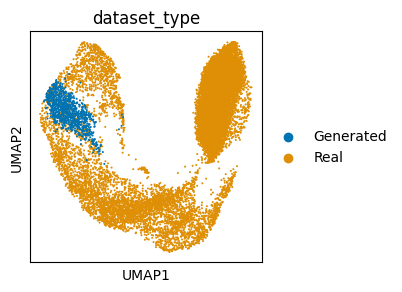

In [25]:
obs = {"dataset_type": ["Real" for _ in range(train_adata.shape[0])] + ["Generated" for _ in range(predicted_perturbations.shape[0])]}
adata_generated = sc.AnnData(X=np.concatenate([perturbation_data, predicted_perturbations], axis=0), obs=obs)
# adata_generated = sc.AnnData(X=np.concatenate([perturbation_data, source.detach().cpu()], axis=0), obs=obs)
adata_generated.obsm["X_pca"] = adata_generated.X.copy()

sc.pp.neighbors(adata_generated)
sc.tl.umap(adata_generated)
# sc.pl.pca(adata_generated, color="dataset_type")
sc.pl.umap(adata_generated, color="dataset_type")

# Plot curves

Check if predictions are what you expect 

In [26]:
pred_tot = {sc_exp_design.constants.DataFields.PERTURBATION_DATA: {"feats_viral_genes_X_pca_condition": trajectory[-1]}}

with torch.no_grad():
    pred_tot = flow_matching.predict(
                                pred_tot,
                                no_grad=False
                            )

In [27]:
with torch.no_grad():
    predicted_class = g_model(pred_tot.cuda())
    real_class = g_model(torch.from_numpy(train_data.adata.obsm["X_pca"]).cuda())

predicted_class = softmax(predicted_class.cpu().numpy(), axis=1)
real_class = softmax(real_class.cpu().numpy(), axis=1)

In [28]:
predicted_class.shape

(1000, 9)

In [29]:
predicted_class_total = np.concatenate([real_class.argmax(1), predicted_class.argmax(1)])

In [30]:
adata_generated.obs["predicted_class"] = predicted_class_total
adata_generated.obs["predicted_class"] = [str(i) for i in adata_generated.obs["predicted_class"]]

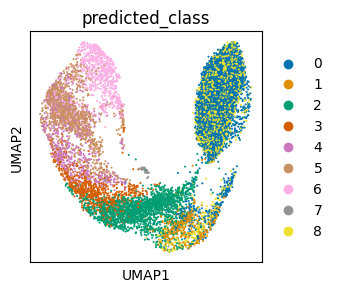

In [31]:
palette = sns.color_palette("colorblind", n_colors=9)

sc.pl.umap(adata_generated, color="predicted_class", palette=palette)

## Check real data accuracy

In [32]:
# (real_class.argmax(1) == train_data.target_data["cluster"]).sum()/real_class.shape[0]

# Check if the predictions make sense in the host expression

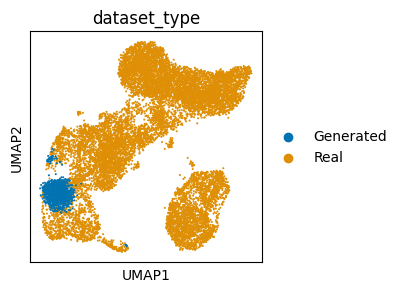

In [33]:
obs = {"dataset_type": ["Real" for _ in range(train_adata.shape[0])] + ["Generated" for _ in range(pred_tot.shape[0])]}
adata_generated = sc.AnnData(X=np.concatenate([train_data.state_data, pred_tot.detach().cpu().numpy()], axis=0), obs=obs)
adata_generated.obsm["X_pca"] = adata_generated.X.copy()

sc.pp.neighbors(adata_generated)
sc.tl.umap(adata_generated)
sc.pl.umap(adata_generated, color="dataset_type")